## Random Forest on Cross Dataset

In [ ]:
import h5py
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
SPECTRA_PATH = 'dataset/spectra.h5'
LABELS_PATH = 'dataset/labels.parquet'

print("Loading Labels...")
labels_df = pd.read_parquet(LABELS_PATH)
target_cols = ['log10_vmr_h2o', 'log10_vmr_co2', 'log10_vmr_co', 'log10_vmr_ch4', 'log10_vsmr_nh3']


print("Loading Spectra...")
with h5py.File(SPECTRA_PATH, 'r') as f_spectra:
    # As per documentation, spectra.h5 and labels.parquet share the exact same ordering.
    spectra = f_spectra['transit_depth_noisy'][:]
    sigma_ppm = f_spectra['sigma_ppm'][:]

X_full = np.column_stack((spectra, sigma_ppm))
y_full = labels_df[target_cols].values

print(f"Features shape: {X_full.shape}")
print(f"Targets shape: {y_full.shape}")

train_mask = labels_df['split'] == 'train'
val_mask = labels_df['split'] == 'val'
test_mask = labels_df['split'] == 'test'

X_train, y_train = X_full[train_mask], y_full[train_mask]
X_val, y_val = X_full[val_mask], y_full[val_mask]
X_test, y_test = X_full[test_mask], y_full[test_mask]

# Scale targets based on training data
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Val shapes: X={X_val.shape}, y={y_val.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Loading Labels...
Loading Spectra...
Features shape: (42108, 219)
Targets shape: (42108, 5)
Train shapes: X=(37281, 219), y=(37281, 5)
Val shapes: X=(4142, 219), y=(4142, 5)
Test shapes: X=(685, 219), y=(685, 5)


In [ ]:
rf_model = MultiOutputRegressor(RandomForestRegressor(
    n_estimators=100,
    n_jobs=-1,
    random_state=42
))

print("Training on crossgen...")
rf_model.fit(X_train, y_train_scaled)
print("Training Complete!")

Training on crossgen_biosignatures_20260311...
Training Complete!


In [ ]:
# Choose your filenames
model_filename = 'our_data_rf_model.joblib'
scaler_filename = 'our_data_scaler_y.joblib'

# Export the trained model
joblib.dump(rf_model, model_filename)
print(f"Model saved to {model_filename}")

# Export the fitted scaler
joblib.dump(scaler_y, scaler_filename)
print(f"Scaler saved to {scaler_filename}")

Model saved to our_data_rf_model.joblib
Scaler saved to our_data_scaler_y.joblib


### Validation on test set (POSEIDON)

============= QEML & RMSE BENCHMARK RESULTS =============
Test Set: POSEIDON (685 samples)\n
log10_vmr_h2o   | Acc (<=5%):  36.35% | R2: -0.1050 | RMSE: 3.0192
log10_vmr_co2   | Acc (<=5%):  37.52% | R2: -0.2922 | RMSE: 3.3703
log10_vmr_co    | Acc (<=5%):  32.55% | R2: -0.0819 | RMSE: 2.9568
log10_vmr_ch4   | Acc (<=5%):  37.37% | R2: -0.1980 | RMSE: 3.2184
log10_vmr_nh3   | Acc (<=5%):  36.20% | R2: -0.1072 | RMSE: 2.9899


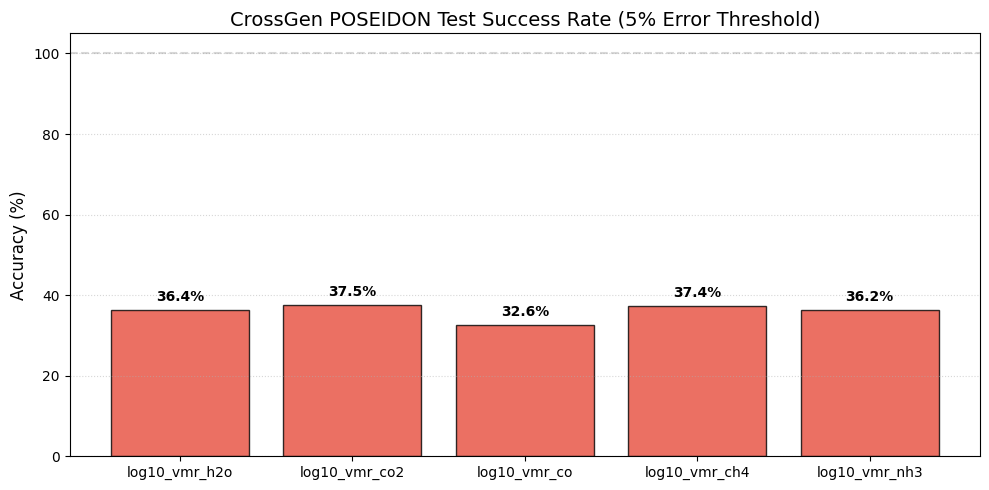

In [ ]:
y_pred_scaled = rf_model.predict(X_test)
y_pred_unscaled = scaler_y.inverse_transform(y_pred_scaled)

def qeml_accuracy(y_true, y_pred, threshold=5.0):
    denominator = np.where(y_true == 0, 1e-12, y_true)
    relative_error = ((y_true - y_pred)**2 / (denominator)**2) * 100
    successful_retrievals = relative_error <= threshold
    return np.mean(successful_retrievals) * 100

print("============= QEML & RMSE BENCHMARK RESULTS =============")
print("Test Set: POSEIDON (685 samples)\\n")

accuracies = []
r2_scores = []
rmses = []

for i, name in enumerate(target_cols):
    acc = qeml_accuracy(y_test[:, i], y_pred_unscaled[:, i], threshold=5.0)
    r2 = r2_score(y_test[:, i], y_pred_unscaled[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred_unscaled[:, i]))
    
    accuracies.append(acc)
    r2_scores.append(r2)
    rmses.append(rmse)
    
    print(f"{name:15} | Acc (<=5%): {acc:6.2f}% | R2: {r2:6.4f} | RMSE: {rmse:6.4f}")

# PLOT ACCURACIES
plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if a > 80 else '#3498db' if a > 50 else '#e74c3c' for a in accuracies]
bars = plt.bar(target_cols, accuracies, color=colors, edgecolor='black', alpha=0.8)

plt.ylim(0, 105)
plt.axhline(y=100, color='gray', linestyle='--', alpha=0.3)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("CrossGen POSEIDON Test Success Rate (5% Error Threshold)", fontsize=14)
plt.grid(axis='y', linestyle=':', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.1f}%",
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

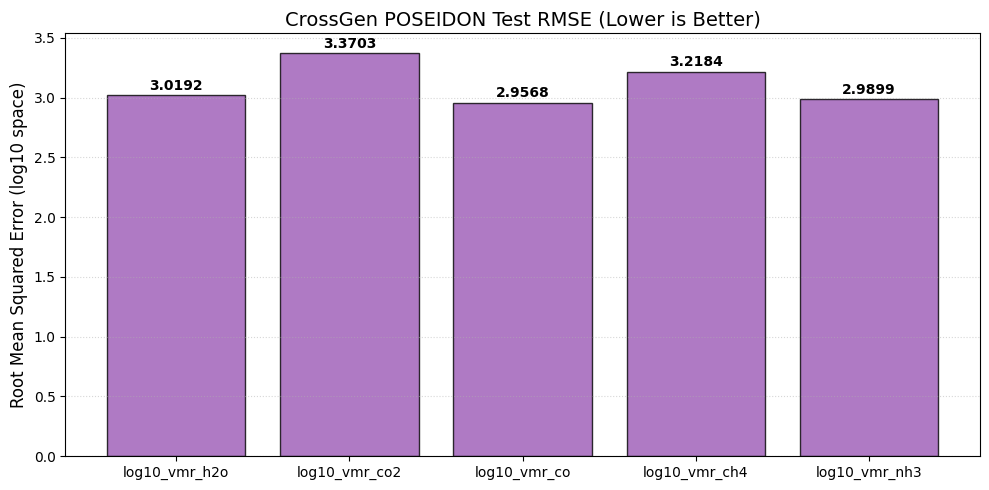

In [ ]:
plt.figure(figsize=(10, 5))

bars_rmse = plt.bar(target_cols, rmses, color='#9b59b6', edgecolor='black', alpha=0.8)

plt.ylabel("Root Mean Squared Error (log10 space)", fontsize=12)
plt.title("CrossGen POSEIDON Test RMSE (Lower is Better)", fontsize=14)
plt.grid(axis='y', linestyle=':', alpha=0.5)

for bar in bars_rmse:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.4f}",
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Validation on validation set (TauREx)

============= QEML & RMSE BENCHMARK RESULTS =============
Validation Set: TauREx (4,142 samples)

log10_vmr_h2o   | Acc (<=5%):  49.66% | R2: 0.4251 | RMSE: 2.1719
log10_vmr_co2   | Acc (<=5%):  63.81% | R2: 0.6579 | RMSE: 1.6928
log10_vmr_co    | Acc (<=5%):  37.40% | R2: 0.1346 | RMSE: 2.7110
log10_vmr_ch4   | Acc (<=5%):  65.04% | R2: 0.6604 | RMSE: 1.6628
log10_vmr_nh3   | Acc (<=5%):  53.96% | R2: 0.5426 | RMSE: 1.9603


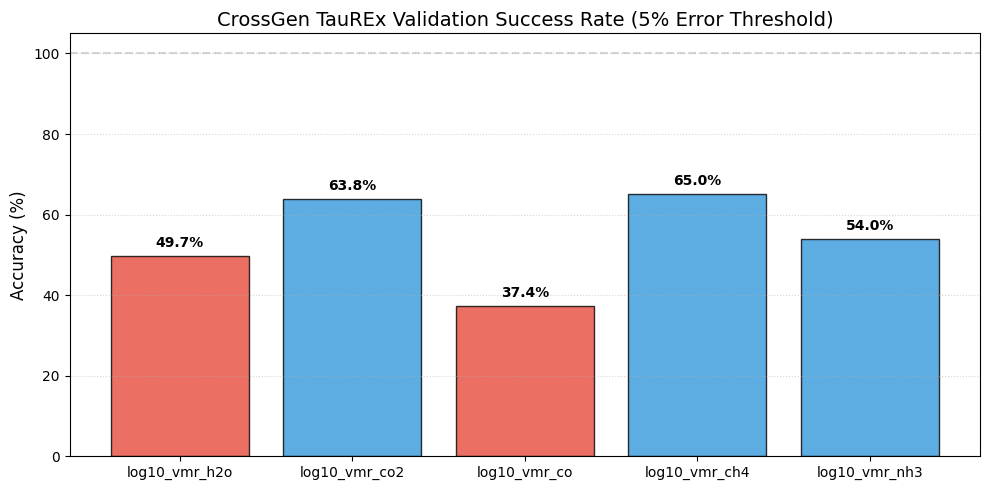

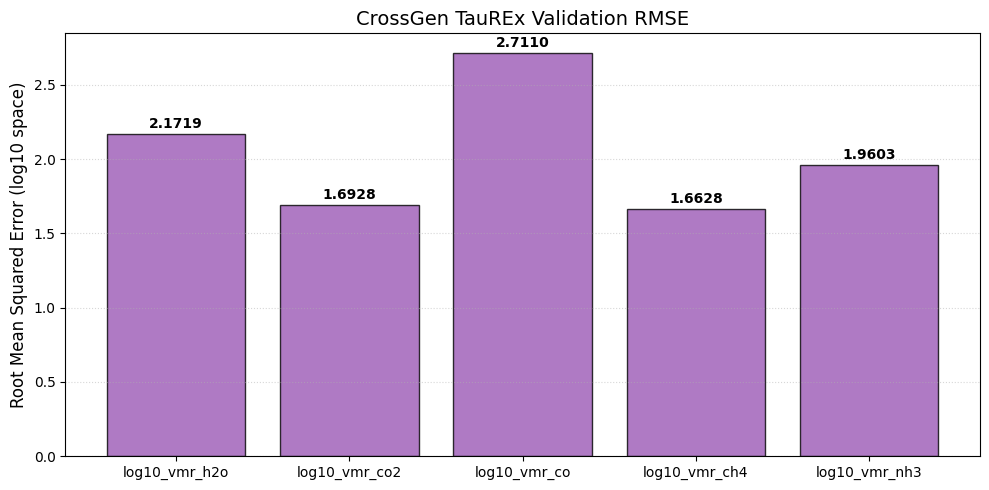

In [ ]:
y_val_pred_scaled = rf_model.predict(X_val)
y_val_pred_unscaled = scaler_y.inverse_transform(y_val_pred_scaled)

print("============= QEML & RMSE BENCHMARK RESULTS =============")
print("Validation Set: TauREx (4,142 samples)\n")

val_accuracies = []
val_r2_scores = []
val_rmses = []

for i, name in enumerate(target_cols):
    acc = qeml_accuracy(y_val[:, i], y_val_pred_unscaled[:, i], threshold=5.0)
    r2 = r2_score(y_val[:, i], y_val_pred_unscaled[:, i])
    rmse = np.sqrt(mean_squared_error(y_val[:, i], y_val_pred_unscaled[:, i]))
    
    val_accuracies.append(acc)
    val_r2_scores.append(r2)
    val_rmses.append(rmse)
    
    print(f"{name:15} | Acc (<=5%): {acc:6.2f}% | R2: {r2:6.4f} | RMSE: {rmse:6.4f}")


plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if a > 80 else '#3498db' if a > 50 else '#e74c3c' for a in val_accuracies]
bars = plt.bar(target_cols, val_accuracies, color=colors, edgecolor='black', alpha=0.8)

plt.ylim(0, 105)
plt.axhline(y=100, color='gray', linestyle='--', alpha=0.3)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("CrossGen TauREx Validation Success Rate (5% Error Threshold)", fontsize=14)
plt.grid(axis='y', linestyle=':', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.1f}%",
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
bars_rmse = plt.bar(target_cols, val_rmses, color='#9b59b6', edgecolor='black', alpha=0.8)

plt.ylabel("Root Mean Squared Error (log10 space)", fontsize=12)
plt.title("CrossGen TauREx Validation RMSE", fontsize=14)
plt.grid(axis='y', linestyle=':', alpha=0.5)

for bar in bars_rmse:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.4f}",
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()